In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hypothesisTesting.ipynb")

## Lecture Section

In this lecture, we will cover more aspects of hypothesis testing. We will rely on the 'statsmodels' library for most of this lecture-assignment.

We will cover:
* ANOVAs
* Power
* z-tests
* * Contingency Tables

In the previous lecture, we learned how to do a one-way ANOVA with `scipy`.

### ANOVA (again!)

We are going to use the `ToothGrowth` dataset from `statsmodels` - it's an R dataset of supplement dosing and tooth growth.

In [4]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.libqsturng import psturng
from statsmodels.stats.multicomp import MultiComparison
from statsmodels.imputation.mice import MICEData
import numpy as np


# Let's load the `ToothGrowth` dataset and examine whether supplement type and dose affect tooth length.
df2 = sm.datasets.get_rdataset("ToothGrowth", "datasets").data
df2["dose"] = df2["dose"].astype("category")
df2.head()


,len,supp,dose
0,4.2,VC,0.5
1,11.5,VC,0.5
2,7.3,VC,0.5
3,5.8,VC,0.5
4,6.4,VC,0.5


### ANOVA

Let's start with ANOVAs. We already covered a one-way test with `scipy`, but we can do the same with `statsmodels`. Let's test whether supplement type affects tooth length. First, we create a linear regression model with `smf.ols()`. Then, we use `statsmodels.api as sm` to call `anova_lm()`. We use `typ=2` to denote that there are no interaction effects.

In [5]:
model = smf.ols("len ~ C(dose)", data=df2).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

               sum_sq    df          F        PR(>F)
C(dose)   2426.434333   2.0  67.415738  9.532727e-16
Residual  1025.775000  57.0        NaN           NaN


### 2-Way Anova

We do the same for a two-way ANOVA. We add the other predictor variable to our regression model, then run the `.anova_lm()` function again. Notice the interaction term we use: `C(supp):C(dose)` - we use it to show how the effect of the supplement depends on the dose.

The [T.VC], [T.1.0], etc. in the rest of our results represent the other categories within our dataset. They are dummy variables!

In [6]:
model2 = smf.ols("len ~ C(supp) + C(dose) + C(supp):C(dose)", data=df2).fit()
print(sm.stats.anova_lm(model2, typ=2))
print(model2.summary())

                      sum_sq    df          F        PR(>F)
C(supp)           205.350000   1.0  15.571979  2.311828e-04
C(dose)          2426.434333   2.0  91.999965  4.046291e-18
C(supp):C(dose)   108.319000   2.0   4.106991  2.186027e-02
Residual          712.106000  54.0        NaN           NaN
                            OLS Regression Results                            
Dep. Variable:                    len   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     41.56
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.50e-17
Time:                        01:46:46   Log-Likelihood:                -159.35
No. Observations:                  60   AIC:                             330.7
Df Residuals:                      54   BIC:                             343.3
Df Model:                           5                               

Heading back to the one-way ANOVA... let's get more information. We can run `pairwise_tukeyhsd()` from `statsmodels.stats.multicomp` - it's a type of post-hoc test that makes pairwise comparisons between the means  of each group.

If we compare the mean tooth lengths of each dose group, we see that the differences between all three groups of doses are meaningful!

In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df2["len"],
                          groups=df2["dose"],
                          alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   0.5    1.0     9.13   0.0  5.9018 12.3582   True
   0.5    2.0   15.495   0.0 12.2668 18.7232   True
   1.0    2.0    6.365   0.0  3.1368  9.5932   True
---------------------------------------------------


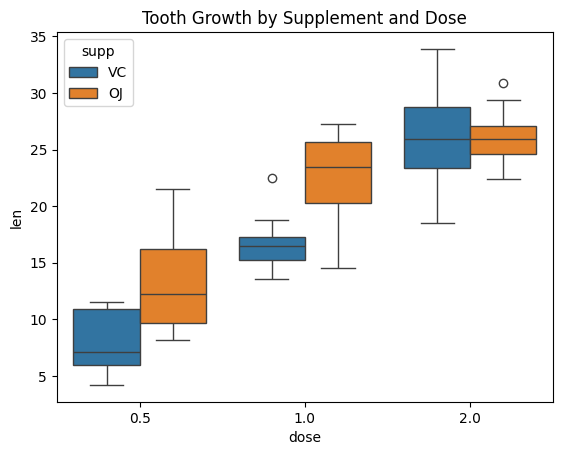

In [8]:
sns.boxplot(data=df2, x="dose", y="len", hue="supp")
plt.title("Tooth Growth by Supplement and Dose")
plt.show()

### Power

Let's take a quick detour and talk about statistical power. `statsmodels` has a lot of different functions to help you determine statistical power - we will try a couple.

This first one is a class called TTestIndPower. It holds many methods for determining power of an independant two-sample t-test. `.power()` will find the power.

In [9]:
from statsmodels.stats.power import TTestIndPower
power_analysis = TTestIndPower()
power = power_analysis.power(effect_size=0.4, nobs1=100, alpha=0.05)
print("Power: ", power)

Power:  0.8036475044212659


We can also use `.solve_power()`. This method solves for a missing parameter of your choosing. In the case below, I am solving for sample size to reach a power of 0.8 with a 95% confidence and an effect size of 0.4.

In [10]:
from statsmodels.stats.power import TTestIndPower
power_analysis = TTestIndPower()
power = power_analysis.solve_power(effect_size=0.4, nobs1=None, alpha=0.05, power = 0.8)
print("Value: ", power)

Value:  99.08032514676718


`statsmodels` has similar functions for normal distributions, chi-square, and ANOVAs.

### z-tests

(We are going to use the `tips` dataset for this portion.)

Finally, let's talk about z-tests in Python. They are similar to t-tests, but they compare to a known population value. We will pretend that average tips nationwide is $3, and we will pretend to know the population variances follow a normal distribution.

To perform a one-sample z-test, we use `statsmodels.stats.weightstats` and import `ztest`. Then, we pass our column of data as the first argument, and our population value as the second.

In [11]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [12]:
from statsmodels.stats.weightstats import ztest
overall_mean = 3
z_stat, p_val = ztest(tips["tip"], value=overall_mean)
print("One-sample z-test: z = ", z_stat, " p-value = ", p_val)

One-sample z-test: z =  -0.01943264142291688  p-value =  0.984495971230584


For a two-sample z-test, we use the same function but our second argument is just our second column of data.

In [13]:
male_tips = tips[tips["sex"] == "Male"]["tip"]
female_tips = tips[tips["sex"] == "Female"]["tip"]
z_stat2, p_val2 = ztest(male_tips, female_tips)
print("Two-sample z-test: z = ", z_stat2, " p-value = ", p_val2)

Two-sample z-test: z =  1.3878597054212687  p-value =  0.1651797698624794


### Contingency Table

We've worked quite a bit without visualizing our categorical variables and their class labels in a contingency table. 'statsmodels' makes this easy for us.

In [14]:
import pandas as pd
import statsmodels.api as sm

df = sm.datasets.get_rdataset("Arthritis", "vcd").data
df.fillna({"Improved":"None"}, inplace=True)
df.head()

,ID,Treatment,Sex,Age,Improved
0,57,Treated,Male,27,Some
1,46,Treated,Male,29,None
2,77,Treated,Male,30,None
3,17,Treated,Male,32,Marked
4,36,Treated,Male,46,Marked


This data shows people with arthritis and whether they had improvement in symptoms after a treatment (or placebo). We want a contingency table of the treatment and the outcome (improvement level). We can use 'sm.stats.Table()' to create a nice table for us.

In [15]:
tab = pd.crosstab(df['Treatment'], df['Improved'])
tab = tab.loc[:, ["None", "Some", "Marked"]]

table = sm.stats.Table(tab)
table.table_orig

Improved,None,Some,Marked
Treatment,,,
Placebo,29,7,7
Treated,13,7,21


We can get the expected cell counts (assuming independence) and compare to our contingency table

In [16]:
table.fittedvalues  # Expected values under independence

Improved,None,Some,Marked
Treatment,,,
Placebo,21.5,7.166667,14.333333
Treated,20.5,6.833333,13.666667


We can see how much each cell deviates from the expected value, too

In [17]:
table.resid_pearson

Improved,None,Some,Marked
Treatment,,,
Placebo,1.617492,-0.062257,-1.936992
Treated,-1.656473,0.063758,1.983673


In [18]:
result = table.test_ordinal_association()
print(result)

null_mean   34.166666666666664
null_sd     4.136517428839106
pvalue      0.00033585683854043673
statistic   49.0
zscore      3.5859472584154544


If your variables are nominal and not ordinal, you can use the nominal version of the same function. We have an ordinal variable in this case, so our p-value will not be as small, but is still statistically significant under most assumptions of alpha!

In [19]:
result = table.test_nominal_association()
print(result)

df          2
pvalue      0.0014626434089526352
statistic   13.055019852524108


## Assignment Section

**Question 1.** Run an ANOVA on the 'penguins' dataset from seaborn. You want to compare the average 'body_mass_g' for each penguin 'species'. Use the 'statsmodels' library this time.

In [21]:
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm


penguins = sns.load_dataset("penguins").dropna()
model = smf.ols("body_mass_g ~ species", data=penguins).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table 

,sum_sq,df,F,PR(>F)
species,1.451902e+08,2.0,341.894895,3.744505e-81
Residual,7.006945e+07,330.0,NaN,NaN


In [22]:
grader.check("q1")

q1 results: All test cases passed!

**Question 2.** Create a 2-way ANOVA similar to the above problem, but add the categorical variable 'sex'.

In [25]:
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

penguins = sns.load_dataset("penguins").dropna()
model2 = smf.ols("body_mass_g ~ species + sex + species:sex", data=penguins).fit()
print(sm.stats.anova_lm(model2, typ=2))
print(model2.summary())

                   sum_sq     df           F         PR(>F)
species      1.434016e+08    2.0  749.015666  8.144406e-123
sex          3.709026e+07    1.0  387.459976   1.902273e-57
species:sex  1.676557e+06    2.0    8.756997   1.973489e-04
Residual     3.130263e+07  327.0         NaN            NaN
                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     384.3
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.54e-134
Time:                        01:58:52   Log-Likelihood:                -2379.1
No. Observations:                 333   AIC:                             4770.
Df Residuals:                     327   BIC:                             4793.
Df Model:                           5                               

In [26]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

**Question 3.** Create a boxplot of 'body_mass_g' (y), 'species' (x), and colored by 'sex'.

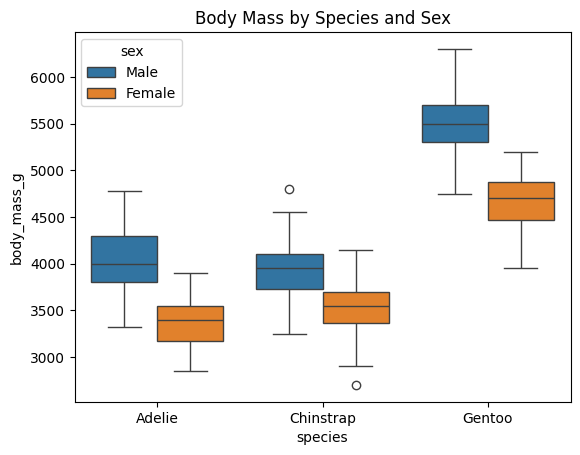

In [28]:
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="sex")
plt.title("Body Mass by Species and Sex")
plt.show()

<!-- END QUESTION -->

**Question 4.** Let's assume the 'penguins' dataset is representative sample of a population of penguins who's mean body_mass_g is 4200. Do a z-test and calculate whether the mean of our sample differs from the true population mean of 4200.

In [31]:
from statsmodels.stats.weightstats import ztest
import seaborn as sns
import numpy as np

overall_mean = 4200
z_stat, p_val = ztest(penguins["body_mass_g"], value= overall_mean)
print("One-sample z-test: z = ", z_stat, " p-value = ", p_val)

One-sample z-test: z =  0.15993129594799477  p-value =  0.8729351952193506


In [32]:
grader.check("q4")

q4 results: All test cases passed!

**Question 5.** Using the 'penguins' dataset, create a contingency table between 'species' and 'sex'. Also give the fitted values in a table, and run a nominal association test.

In [37]:
import seaborn as sns
import pandas as pd
...
tab = pd.crosstab(penguins['species'], penguins['sex'])
#print(tab)

table = sm.stats.Table(tab)
fitted = table.fittedvalues 
result = table.test_nominal_association()



In [38]:
grader.check("q5")

q5 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [39]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!